# Pré-processamento — Breast Cancer Survival Predictor

**Objetivo:** Nosso objetivo com o pre-processamento é limpar, transformar e balancear o dataset para usá-lo nos modelos de Marchine Learning.

### Com isso temos etapas padronizadas seguidas:

1. Carregamento e inspeção
2. Limpeza de dados
3. Encoding de variáveis categóricas
4. Remoção de variável com vazamento de dados
5. Salvamento de dataset processado
6. Divisão treino/teste
7. Normalização das variáveis numéricas
8. Balanceamento com SMOTE
9. Salvamento dos arquivos processados

### Bibliotecas usadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

### 1 Carregamento e Inspeção


Carregamos o dataset bruto diretamente do CSV original e fazemos uma inspeção inicial para entender sua estrutura, seja em número de linhas, colunas e os primeiros registros.

Esta etapa não modifica nenhum dado, serve apenas para confirmar que o arquivo foi lido corretamente e nos dar uma visão geral do que temos.

In [2]:
df1 = pd.read_csv('../data/data_Raw/Breast_Cancer.csv')
print(f'Shape: {df1.shape}')
df1.head()

Shape: (4024, 16)


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


### 2 Limpeza de Dados


Antes da transformação dos dados temos que limpá-los. Precisamos garantir que os dados estejam consistentes e sem problemas estruturais. Esta etapa é feita antes do split (separação de treino e teste) pois não aprende nenhuma estatística dos dados, apenas corrige inconsistências.

Realizamos quatro ações:

- **Verificação e remoção de duplicatas** — linhas idênticas não agregam informação e podem distorcer o aprendizado do modelo
- **Padronização dos nomes de colunas** — removemos espaços extras e substituímos por underline (`T Stage ` → `T_Stage`), evitando erros de acesso às colunas
- **Remoção de espaços nos valores** — alguns valores categóricos tinham espaços invisíveis (`'Single '`), que causariam erros silenciosos no encoding
- **Correção do valor inconsistente em Grade** — o dataset usa `'anaplastic; Grade IV'` para o grau 4, com nome diferente dos demais (`'1'`, `'2'`, `'3'`). Padronizamos para `'4'` para manter consistência e permitir conversão para inteiro

In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

In [4]:
print(f"Este dataset possui {df1.duplicated().sum()} duplicata(s)")

Este dataset possui 1 duplicata(s)


In [5]:
duplicatas = df1[df1.duplicated()]
df1[df1.duplicated(keep=False)]
df1 = df1.drop_duplicates()

In [6]:
df1.columns.tolist()

['Age',
 'Race',
 'Marital Status',
 'T Stage ',
 'N Stage',
 '6th Stage',
 'differentiate',
 'Grade',
 'A Stage',
 'Tumor Size',
 'Estrogen Status',
 'Progesterone Status',
 'Regional Node Examined',
 'Reginol Node Positive',
 'Survival Months',
 'Status']

In [7]:
df1.columns = df1.columns.str.strip().str.replace(' ', '_')

cat_cols = df1.select_dtypes(include='object').columns

for col in cat_cols:
    df1[col] = df1[col].str.strip()


In [8]:
print('Antes:', df1['Grade'].unique())
df1['Grade'] = df1['Grade'].replace('anaplastic; Grade IV', '4')
print('Depois:', df1['Grade'].unique())

Antes: ['3' '2' '1' 'anaplastic; Grade IV']
Depois: ['3' '2' '1' '4']


### 3 — Encoding de Variáveis Categóricas

Antes de qualquer processamento fizemos uma cópia, para caso de alguma coisa de errado não perdermos a limpeza realizada no Dataframe, logo após seguindo com o processamento de encoding dos dados, até por que os modelos de Machine Learning trabalham apenas com números. Todas as variáveis categóricas precisaram serem transformadas em valores numéricos antes do treinamento.

Essa etapa foi feita antes do split para garantir que treino e teste usem exatamente os mesmos mapeamentos, evitando inconsistências entre os conjuntos.

Foram usadas duas estratégias:

### Ordinal Encoding

Usado nas variáveis que têm uma ordem natural. Os números representam aumento de gravidade ou avanço da doença:

- `Grade`: 1 (melhor diferenciação) → 4 (mais agressivo)
- `T_Stage`: T1 (tumor menor) → T4 (tumor maior)
- `N_Stage`: N1 (menos linfonodos comprometidos) → N3 (mais comprometidos)
- `6th_Stage`: IIA → IIIC (estágios mais avançados)
- `differentiate`: Well → Undifferentiated (mais agressivo)

### Label Encoding

Usado nas variáveis sem ordem natural, com os números sendo atribuídos apenas para representar as categorias:

- `Race`
- `Marital_Status`
- `A_Stage`
- `Estrogen_Status`
- `Progesterone_Status`

### Target

A variável alvo `Status` foi convertida manualmente:

- `Alive = 0`
- `Dead = 1`

A classe `Dead` foi definida como positiva por representar o evento clínico mais importante a ser identificado pelo modelo.

In [9]:
df2 = df1.copy()

#Ordinal Encoding
df2['Grade'] = df2['Grade'].astype(int)

df2['T_Stage'] = df2['T_Stage'].map({'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4})

df2['N_Stage'] = df2['N_Stage'].map({'N1': 1, 'N2': 2, 'N3': 3})

df2['6th_Stage'] = df2['6th_Stage'].map({'IIA': 1, 'IIB': 2, 'IIIA': 3, 'IIIB': 4, 'IIIC': 5})

df2['differentiate'] = df2['differentiate'].map({
    'Well differentiated': 1,
    'Moderately differentiated': 2,
    'Poorly differentiated': 3,
    'Undifferentiated': 4
})

df2[['Grade', 'T_Stage', 'N_Stage', '6th_Stage', 'differentiate']].head()

,Grade,T_Stage,N_Stage,6th_Stage,differentiate
0,3,1,1,1,3
1,2,2,2,3,2
2,2,3,3,5,2
3,3,1,1,1,3
4,3,2,1,2,3


In [10]:
#Label Encoding

le = LabelEncoder()
label_cols = ['Race', 'Marital_Status', 'A_Stage', 'Estrogen_Status', 'Progesterone_Status']

for col in label_cols:
    df2[col] = le.fit_transform(df2[col])

In [11]:
df2['Status'] = df2['Status'].map({'Alive': 0, 'Dead': 1})

print('Distribuição do target:')
print(df2['Status'].value_counts())
print('\n  0 = Alive | 1 = Dead')

Distribuição do target:
Status
0    3407
1     616
Name: count, dtype: int64

  0 = Alive | 1 = Dead


### 4 Remoção de variável com vazamento de dados
Foi percebido que a variável `Survival_Months` não funcionaria adequadamente para a previsão do modelo, porque ela representa uma informação futura — ou seja, quantos meses o paciente sobreviveu após o diagnóstico.

Na prática, quando o médico for utilizar o sistema para fazer uma previsão, esse dado ainda não existirá. Se essa variável fosse mantida, o modelo acabaria “trapaceando”: ao ver que um paciente sobreviveu muitos meses, ele concluiria facilmente que o paciente está vivo, sem realmente aprender os padrões clínicos importantes.

Esse problema é conhecido como **data leakage**, quando o modelo recebe informações que só seriam conhecidas depois do desfecho.

Por isso, `Survival_Months` foi usada apenas durante a análise exploratória (EDA), mas removida antes do treinamento do modelo.

In [12]:
df2 = df2.drop(columns=['Survival_Months'], errors='ignore')

print(f'Shape: {df2.shape}')
print(f'Features: {df2.drop(columns=["Status"]).columns.tolist()}')

Shape: (4023, 15)
Features: ['Age', 'Race', 'Marital_Status', 'T_Stage', 'N_Stage', '6th_Stage', 'differentiate', 'Grade', 'A_Stage', 'Tumor_Size', 'Estrogen_Status', 'Progesterone_Status', 'Regional_Node_Examined', 'Reginol_Node_Positive']


### 5 salvamento de dataset processado

Foi tomada a decisão de salvar um arquivo central do dataset após toda a etapa de limpeza e encoding dos dados. Assim, caso seja necessário treinar novos modelos futuramente, já existe um CSV pré-processado pronto para uso.

O dataset foi salvo antes do split e da normalização, servindo como uma versão principal e padronizada dos dados para análises futuras, novos testes, visualizações ou retreinamentos com estratégias diferentes.

> As variáveis numéricas ainda permanecem na escala original, já que a normalização só acontece depois da separação entre treino e teste.

In [13]:
os.makedirs('../data/processed_data', exist_ok=True)

df2.to_csv('../data/processed_data/Breast_Cancer_processed.csv', index=False)

### 6 Divisão treino/teste
O dataset foi dividido em dois grupos: treino (80%) e teste (20%). O modelo aprende os padrões usando os dados de treino e depois é avaliado com os dados de teste, que funcionam como exemplos nunca vistos antes pelo próprio.

Essa separação é feita antes da normalização e do SMOTE para evitar que informações do conjunto de teste acabem influenciando o treinamento do modelo.

Foram utilizados os seguintes parâmetros:

- `test_size=0.2` → separa 20% dos dados para teste e 80% para treino
- `random_state=42` → garante que a divisão seja sempre igual em cada execução
- `stratify=y` → mantém a mesma proporção entre `Alive` e `Dead` nos dois conjuntos

In [15]:
X = df2.drop(columns=['Status'])
y = df2['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Treino: {X_train.shape} | Alive: {(y_train==0).sum()} | Dead: {(y_train==1).sum()}')
print(f'Teste:  {X_test.shape}  | Alive: {(y_test==0).sum()}  | Dead: {(y_test==1).sum()}')

Treino: (3218, 14) | Alive: 2725 | Dead: 493
Teste:  (805, 14)  | Alive: 682  | Dead: 123


### 7 Normalização das variáveis numéricas
Foi aplicado o `MinMaxScaler` nas variáveis numéricas contínuas para deixar todos os valores em uma mesma escala, entre 0 e 1.

Isso ajuda o modelo a tratar as variáveis de forma mais equilibrada. Sem normalização, colunas com números maiores, como `Tumor_Size`, poderiam acabar tendo mais influência que outras variáveis, como `Age`, apenas pelo tamanho dos valores.

A normalização foi feita somente depois do split para evitar data leakage.

O processo aconteceu assim:

- `fit_transform` no treino: o scaler aprende os valores mínimos e máximos usando apenas os dados de treino
- `transform` no teste: aplica exatamente os mesmos parâmetros no conjunto de teste, sem reaprender nada


In [16]:
scaler = MinMaxScaler()
num_cols = ['Age', 'Tumor_Size', 'Regional_Node_Examined', 'Reginol_Node_Positive']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Escala 0 a 1).')
X_train[num_cols].describe().round(3).T

Escala 0 a 1).


,count,mean,std,min,25%,50%,75%,max
Age,3218.0,0.615,0.230,0.0,0.436,0.615,0.795,1.0
Tumor_Size,3218.0,0.212,0.152,0.0,0.108,0.173,0.266,1.0
Regional_Node_Examined,3218.0,0.238,0.144,0.0,0.143,0.232,0.321,1.0
Reginol_Node_Positive,3218.0,0.070,0.114,0.0,0.000,0.022,0.089,1.0


### 8 Balanceamento com SMOTE
O dataset original possui muito mais pacientes `Alive` do que `Dead`, com uma proporção de aproximadamente **5,5 para 1**.

Sem corrigir esse desbalanceamento, o modelo poderia simplesmente prever quase tudo como `Alive` e ainda alcançar uma acurácia alta (~85%), mas na prática isso seria inútil, já que ele teria dificuldade para identificar pacientes realmente em risco.

Para resolver isso, foi utilizado o SMOTE.

O SMOTE cria novos exemplos sintéticos da classe com menos dados (`Dead`) a partir de pacientes reais parecidos, gerando novos pontos plausíveis em vez de apenas copiar registros existentes.

O balanceamento foi aplicado somente no conjunto de treino. O conjunto de teste permaneceu original para representar melhor a distribuição real dos dados e permitir uma avaliação mais confiável do modelo.

In [17]:
print(type(y_train.iloc[0]))
print(y_train.unique())
print(y_train.value_counts())

<class 'numpy.int64'>
[0 1]
Status
0    2725
1     493
Name: count, dtype: int64


In [19]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Antes do SMOTE:')
print(f'  Alive: {(y_train==0).sum()} | Dead: {(y_train==1).sum()}')
print()
print('Após o SMOTE:')
print(f'  Alive: {(y_train_bal==0).sum()} | Dead: {(y_train_bal==1).sum()}')
print(f'  Ratio: 1:1')

Antes do SMOTE:
  Alive: 2725 | Dead: 493

Após o SMOTE:
  Alive: 2725 | Dead: 2725
  Ratio: 1:1


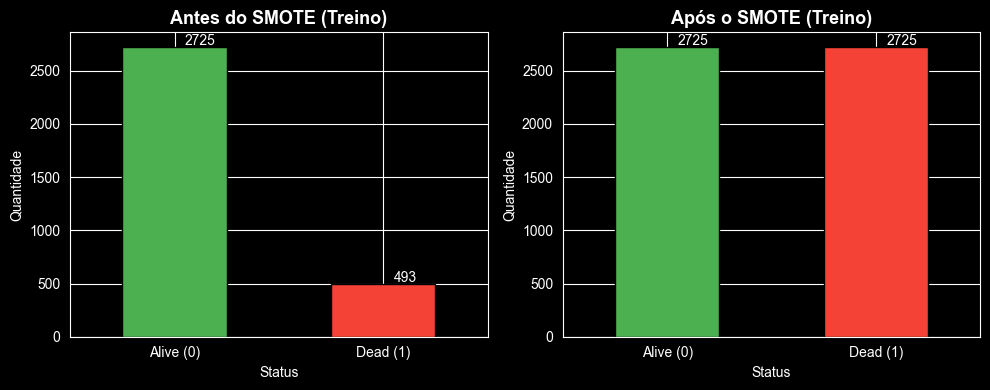

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

y_train.value_counts().plot(
    kind='bar', ax=axes[0], color=['#4CAF50', '#F44336'], edgecolor='black'
)
axes[0].set_title('Antes do SMOTE (Treino)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Alive (0)', 'Dead (1)'], rotation=0)
axes[0].set_ylabel('Quantidade')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())), (p.get_x() + 0.3, p.get_height() + 20))

pd.Series(y_train_bal).value_counts().plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#F44336'], edgecolor='black'
)
axes[1].set_title('Após o SMOTE (Treino)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Alive (0)', 'Dead (1)'], rotation=0)
axes[1].set_ylabel('Quantidade')
for p in axes[1].patches:
    axes[1].annotate(str(int(p.get_height())), (p.get_x() + 0.3, p.get_height() + 20))

plt.tight_layout()
plt.savefig('../assets/charts_images/distributions/smote_balanceamento.png', dpi=150)
plt.show()

### 9 Salvamento dos arquivos processados

Salvamento dos arquivos processados que serão utilizados no treinamento dos modelos

In [21]:
pd.DataFrame(X_train_bal, columns=X.columns).to_csv('../data/processed_data/X_train.csv', index=False)
pd.Series(y_train_bal, name='Status').to_csv('../data/processed_data/y_train.csv', index=False)
X_test.to_csv('../data/processed_data/X_test.csv', index=False)
y_test.to_csv('../data/processed_data/y_test.csv', index=False)